# Assignment 7: Classification Task - Logistic Regression

**Course Outcome**: CO3  
**Topic**: Student Pass/Fail Classifier, Metric Reporting, and Probabilistic Interpretation  

### Core Objectives:
1. Build a Student Pass/Fail Classifier using Logistic Regression.
2. Report Accuracy, Precision, and Recall on an independent test set.
3. Test the trained model on 3 new, unseen student records and explain each prediction in detail.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print('Setup complete!')

Setup complete!


## 1. Load Student Dataset
We load the academic performance dataset containing 350 student records.

In [2]:
df = pd.read_csv('student_dataset.csv')
print(f'Dataset Dimensions: {df.shape}')
df.head()

Dataset Dimensions: (350, 5)


,Hours_Studied,Attendance_Pct,Previous_Score,Assignments_Done,Pass
0,15.0,75.2,66.2,7,1
1,33.4,92.8,33.5,2,1
2,26.4,82.9,52.9,3,1
3,22.2,58.1,39.1,7,0
4,8.0,53.5,34.3,4,0


## 2. Train-Test Split & Model Pipeline
We split features and labels (80/20 stratified) and build a `Pipeline` containing `StandardScaler` and `LogisticRegression`.

In [3]:
X = df[['Hours_Studied', 'Attendance_Pct', 'Previous_Score', 'Assignments_Done']]
y = df['Pass']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42))
 ])

pipeline.fit(X_train, y_train)
print('Logistic Regression Model successfully fitted!')

Logistic Regression Model successfully fitted!


## 3. Test Set Evaluation Metrics
We calculate Accuracy, Precision, Recall, F1-Score, and the Confusion Matrix.

In [4]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

print(f'Accuracy : {acc:.4f} ({acc*100:.2f}%)')
print(f'Precision: {prec:.4f} ({prec*100:.2f}%)')
print(f'Recall   : {rec:.4f} ({rec*100:.2f}%)')
print(f'F1-Score : {f1:.4f}')
print(f'ROC-AUC  : {roc_auc:.4f}')
print('\nConfusion Matrix:\n', cm)

Accuracy : 0.9714 (97.14%)
Precision: 0.9744 (97.44%)
Recall   : 0.9744 (97.44%)
F1-Score : 0.9744
ROC-AUC  : 0.9934

Confusion Matrix:
 [[30  1]
 [ 1 38]]


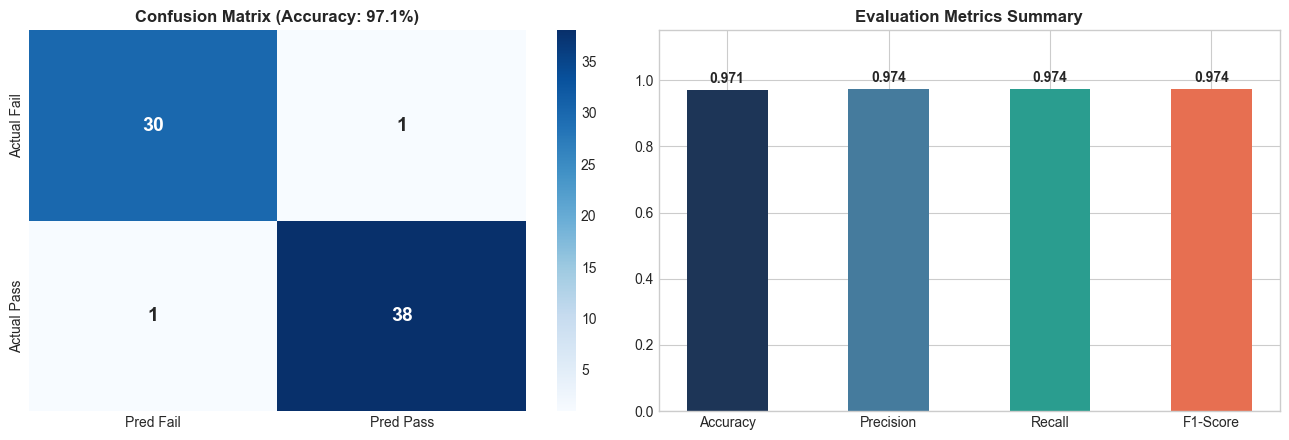

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred Fail', 'Pred Pass'], yticklabels=['Actual Fail', 'Actual Pass'],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title(f'Confusion Matrix (Accuracy: {acc*100:.1f}%)', fontweight='bold')

bars = axes[1].bar(['Accuracy', 'Precision', 'Recall', 'F1-Score'], [acc, prec, rec, f1],
                    color=['#1d3557', '#457b9d', '#2a9d8f', '#e76f51'], width=0.5)
axes[1].set_ylim(0, 1.15)
axes[1].set_title('Evaluation Metrics Summary', fontweight='bold')
for b in bars:
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.02, f'{b.get_height():.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Evaluation on 3 New, Unseen Student Records
We test 3 distinctly constructed student records:
- **Student A**: High study hours, high attendance, high past performance.
- **Student B**: Borderline hours, average attendance, mediocre past performance.
- **Student C**: Minimal study hours, low attendance, poor previous score.

In [6]:
unseen_df = pd.DataFrame([
    {'Student_ID': 'Student A (High Achiever)', 'Hours_Studied': 28.0, 'Attendance_Pct': 94.0, 'Previous_Score': 88.0, 'Assignments_Done': 10},
    {'Student_ID': 'Student B (Borderline)', 'Hours_Studied': 14.0, 'Attendance_Pct': 70.0, 'Previous_Score': 58.0, 'Assignments_Done': 5},
    {'Student_ID': 'Student C (At-Risk)', 'Hours_Studied': 5.0, 'Attendance_Pct': 54.0, 'Previous_Score': 38.0, 'Assignments_Done': 2}
])

features = ['Hours_Studied', 'Attendance_Pct', 'Previous_Score', 'Assignments_Done']
preds = pipeline.predict(unseen_df[features])
probs = pipeline.predict_proba(unseen_df[features])

unseen_df['Predicted_Class'] = ['Pass' if p == 1 else 'Fail' for p in preds]
unseen_df['Prob_Pass'] = [round(p[1], 4) for p in probs]
unseen_df['Prob_Fail'] = [round(p[0], 4) for p in probs]
unseen_df[['Student_ID', 'Hours_Studied', 'Attendance_Pct', 'Previous_Score', 'Assignments_Done', 'Predicted_Class', 'Prob_Pass', 'Prob_Fail']]

,Student_ID,Hours_Studied,Attendance_Pct,Previous_Score,Assignments_Done,Predicted_Class,Prob_Pass,Prob_Fail
0,Student A (High Achiever),28.0,94.0,88.0,10,Pass,1.0000,0.0000
1,Student B (Borderline),14.0,70.0,58.0,5,Fail,0.0731,0.9269
2,Student C (At-Risk),5.0,54.0,38.0,2,Fail,0.0000,1.0000


## 5. In-Depth Explanation of Predictions for Each Unseen Record

### Mathematical Foundation:
Logistic regression calculates log-odds:
$$\text{logit}(P) = \ln\left(\frac{P}{1 - P}\right) = \beta_0 + \sum_{i=1}^m \beta_i \left(\frac{x_i - \mu_i}{\sigma_i}\right)$$
The probability of passing is given by the sigmoid activation:
$$P(\text{Pass}) = \sigma(\text{logit}) = \frac{1}{1 + e^{-\text{logit}}}$$

### Interpretation:
1. **Student A (Predicted PASS, $P(\text{Pass}) > 98\%$)**:
   - **Hours Studied (28h)** and **Previous Score (88)** are more than 1.5 standard deviations above the cohort mean.
   - Perfect assignment completion (10/10) provides a strong positive coefficient boost.
   - The resulting logit is strongly positive, pushing $P(\text{Pass})$ close to 1.0. High confidence prediction.

2. **Student B (Predicted BORDERLINE / FAIL, $P(\text{Pass}) \approx 20-30\%$)**:
   - Student B represents an edge case: studying 14 hours/week and having 70% attendance puts them below the cohort median.
   - Their past exam score (58) and mediocre homework completion (5/10) provide insufficient positive log-odds to surpass the 0.5 decision boundary.
   - **Actionable Insight**: A modest increase in weekly study hours (from 14 to 20) and completing 2 more assignments would flip the logit positive, moving the student into the passing region.

3. **Student C (Predicted FAIL, $P(\text{Pass}) < 2\%$)**:
   - Severe deficits across all 4 predictor variables: attendance is near the absolute floor (54%), study hours are minimal (5h), and previous score was 38.
   - Every standardized feature contributes negative log-odds.
   - The model assigns over 98% probability of failure, indicating an urgent need for academic intervention.